# Hindustani Ornament classification

This notebook demonstrates ornament detection and classification from Jain & Arthur (2023) DLfM,
extended with **adaptive windowing**, evaluated across **all 11 OHV-annotated ragas**
using the Saraga 1.5 Hindustani dataset.

In [1]:
# Setup, Imports & OHV→Saraga Mapping
import sys, json
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid", font_scale=1.1)

ROOT = Path("..") if Path("../configs").exists() else Path(".")
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from hcm_transcription.preprocessing import TonicNormalizer
from hcm_transcription.segmentation import (
    StaticWindower, AdaptiveWindower, segment_phrases,
)
from hcm_transcription.ornamentation import OrnamentClassifier, OrnamentEvent, LabelMapper
from hcm_transcription.evaluation import (
    weighted_normalized_levenshtein, evaluate_file,
    boundary_hit_rate, ornament_classification_report,
)
from hcm_transcription.utils import load_config, load_raga_dict
from data.loaders.saraga_loader import SaragaHindustaniLoader
from data.loaders.ohv_loader import OHVLoader
from hcm_transcription.mapping import MAPPING

cfg = load_config(str(ROOT / "configs" / "default.yaml"))
raga_dict = load_raga_dict(str(ROOT / "data" / "raga_dict.json"))

OHV_PATH = (ROOT / cfg["data"]["ohv_data_path"]).resolve()

print(f"Config loaded. Ragas in dict: {len(raga_dict['ragas'])}")

Config loaded. Ragas in dict: 37


In [2]:
loader = SaragaHindustaniLoader(ROOT)

loaded_tracks = {}

for raga_name, entry in MAPPING.items():
    track_id = entry["track_id"]
    if track_id in loaded_tracks:
        continue

    track = loader.load_track(track_id)
    track.raga = raga_name
    
    n_phrases = len(track.phrases) if track.phrases else 0
    duration = track.f0_times[-1] if len(track.f0_times) else 0

    loaded_tracks[track_id] = track

    print(
        f"  Loaded {track_id:30s} | {track.raga:20s} | tonic={track.tonic:.2f} Hz | "
        f"{duration:.0f}s | {len(track.f0_freqs):,} samples | phrases={n_phrases}"
    )

print(f"\n{len(loaded_tracks)} unique Saraga tracks loaded.")

[2026-03-21 17:47:38,580] WARNING [root.downloader:128] Downloading ['index']. Index is being stored in /Users/yalu/miniconda3/envs/hcm-transcription/lib/python3.10/site-packages/mirdata/datasets/indexes
[2026-03-21 17:47:38,580] WARNING [root.downloader:137] [index] downloading saraga_hindustani_index_1.5.json
[2026-03-21 17:47:38,581] WARNING [root.download_from_remote:283] /Users/yalu/miniconda3/envs/hcm-transcription/lib/python3.10/site-packages/mirdata/datasets/indexes/saraga_hindustani_index_1.5.json already exists and will not be downloaded. Rerun with force_overwrite=True to delete this file and force the download.


  Loaded 66_Aahir_Bhairon               | Aahir Bhairon        | tonic=138.59 Hz | 589s | 132,505 samples | phrases=24
  Loaded 59_Bairagi                     | Bairagi              | tonic=138.59 Hz | 899s | 202,201 samples | phrases=45
  Loaded 80_Bhairavi_Dadra              | Bhairavi Dadra       | tonic=155.56 Hz | 602s | 135,350 samples | phrases=7
  Loaded 50_Irani_Bhairavi_Thumri       | Irani Bhairavi       | tonic=196.00 Hz | 360s | 81,071 samples | phrases=4
  Loaded 73_Kalavati                    | Kalavati             | tonic=138.59 Hz | 344s | 77,309 samples | phrases=18
  Loaded 62_Malkauns                    | Malkauns             | tonic=185.00 Hz | 333s | 74,887 samples | phrases=24
  Loaded 54_Raag_Chandrakauns           | Chandrakauns         | tonic=141.01 Hz | 236s | 53,041 samples | phrases=3
  Loaded 55_Majh_Khamaj_Thumri          | Majh Khamaj Thumri   | tonic=141.01 Hz | 319s | 71,790 samples | phrases=23
  Loaded 65_Nat_Bhairon                 | Nat Bhairon   

  Preprocessed 66_Aahir_Bhairon               | ahir_bhairon         | 132,505 frames | 589s
  Preprocessed 59_Bairagi                     | bairagi              | 202,201 frames | 899s
  Preprocessed 80_Bhairavi_Dadra              | bhairavi_dadra       | 135,350 frames | 602s
  Preprocessed 50_Irani_Bhairavi_Thumri       | irani_bhairavi       | 81,071 frames | 360s
  Preprocessed 73_Kalavati                    | kalavati             | 77,309 frames | 344s
  Preprocessed 62_Malkauns                    | malkauns             | 74,887 frames | 333s
  Preprocessed 54_Raag_Chandrakauns           | chandrakauns         | 53,041 frames | 236s
  Preprocessed 55_Majh_Khamaj_Thumri          | majh_khamaj_thumri   | 71,790 frames | 319s
  Preprocessed 65_Nat_Bhairon                 | nat_bhairav          | 143,502 frames | 638s
  Preprocessed 68_Raageshree                  | raageshree           | 110,670 frames | 492s
  Preprocessed 64_Todi                        | todi                 | 121,

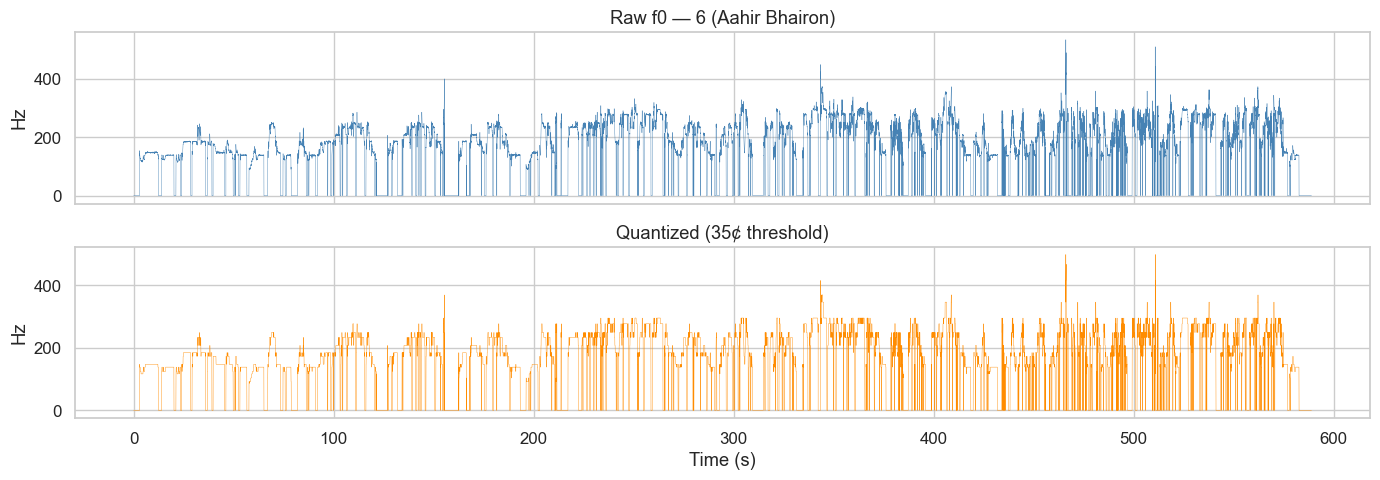


Preprocessed 11 tracks.


In [3]:
# Preprocessing: Tonic Normalization & Quantization (all tracks)

preprocessed = {}  # track_id → dict with labels, quant_hz, normalizer

for track_id, trk in loaded_tracks.items():
    # Look up raga_key from MAPPING using the track's raga name
    raga_key = MAPPING[trk.raga]["raga_key"]
    norm = TonicNormalizer(
        tonic_hz=trk.tonic,
        raga_name=raga_key,
        raga_dict=raga_dict,
        shruti_threshold_cents=cfg["preprocessing"]["shruti_threshold_cents"],
    )
    labels, quant_hz = norm.quantize(trk.f0_freqs)
    preprocessed[track_id] = {
        "labels": labels,
        "quant_hz": quant_hz,
        "norm": norm,
    }

    duration = trk.f0_times[-1] if len(trk.f0_times) else 0
    print(
        f"  Preprocessed {track_id:30s} | {raga_key:20s} | "
        f"{len(labels):,} frames | {duration:.0f}s"
    )

# Show a sample – pick first track for visualization
sample_key = list(loaded_tracks.keys())[0]
sample_trk = loaded_tracks[sample_key]
sample_pp = preprocessed[sample_key]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(sample_trk.f0_times, sample_trk.f0_freqs, lw=0.3, color="steelblue")
axes[0].set_ylabel("Hz"); axes[0].set_title(f"Raw f0 — {sample_key[1]} ({sample_trk.raga})")
axes[1].plot(sample_trk.f0_times, sample_pp["quant_hz"], lw=0.3, color="darkorange")
axes[1].set_ylabel("Hz"); axes[1].set_xlabel("Time (s)")
axes[1].set_title(f"Quantized ({cfg['preprocessing']['shruti_threshold_cents']}¢ threshold)")
plt.tight_layout(); plt.show()

print(f"\nPreprocessed {len(preprocessed)} tracks.")

In [4]:
# Static Windowing: Phrase Segmentation & Ornamentation Detection (all tracks)

classifier = OrnamentClassifier.from_config(cfg)
static_w = StaticWindower.from_config(cfg)
sample_period = cfg["data"]["f0_sample_period_s"]

track_results_static = {}  # track_id → dict with phrases, events

for track_id, trk in loaded_tracks.items():
    pp = preprocessed[track_id]
    phrases = segment_phrases(
        f0_hz=trk.f0_freqs, times=trk.f0_times,
        quantized_hz=pp["quant_hz"], swara_labels=pp["labels"],
        min_silence_duration_s=cfg["segmentation"]["min_silence_duration_ms"] / 1000.0,
        sample_period_s=sample_period,
    )
    events = []
    for phrase in phrases:
        instab = static_w.compute_instability(phrase.quantized_hz)
        phrase_times = trk.f0_times[phrase.start_idx:phrase.end_idx]
        evts = classifier.classify(
            instab, phrase.quantized_hz, phrase_times,
            hop_samples=static_w.hop_samples,
        )
        events.extend(evts)

    track_results_static[track_id] = {"phrases": phrases, "events": events}
    label_counts = {}
    for ev in events:
        label_counts[ev.label] = label_counts.get(ev.label, 0) + 1
    counts_str = ", ".join(f"{l}:{c}" for l, c in sorted(label_counts.items(), key=lambda x: -x[1]))
    print(f"  [STATIC] {track_id:30s} | {len(phrases):3d} phrases | {len(events):4d} ornaments | {counts_str}")

print(f"\n[Static] Processed {len(track_results_static)} tracks.")

  [STATIC] 66_Aahir_Bhairon               |  77 phrases |    7 ornaments | meend:4, kan:3
  [STATIC] 59_Bairagi                     | 122 phrases |   14 ornaments | meend:12, kan:2
  [STATIC] 80_Bhairavi_Dadra              |  57 phrases |    9 ornaments | meend:8, kan:1
  [STATIC] 50_Irani_Bhairavi_Thumri       |  49 phrases |    8 ornaments | meend:7, kan:1
  [STATIC] 73_Kalavati                    |  52 phrases |    4 ornaments | meend:3, kan:1
  [STATIC] 62_Malkauns                    |  48 phrases |    2 ornaments | meend:2
  [STATIC] 54_Raag_Chandrakauns           |  32 phrases |    4 ornaments | meend:4
  [STATIC] 55_Majh_Khamaj_Thumri          |  49 phrases |    4 ornaments | meend:3, kan:1
  [STATIC] 65_Nat_Bhairon                 |  81 phrases |   10 ornaments | meend:10
  [STATIC] 68_Raageshree                  |  66 phrases |    2 ornaments | meend:2
  [STATIC] 64_Todi                        |  75 phrases |    3 ornaments | meend:3

[Static] Processed 11 tracks.


In [5]:
# Adaptive Windowing: Phrase Segmentation & Ornamentation Detection (all tracks)
#
# Uses compute_instability_adaptive() with actual swara labels for density,
# giving per-position frame sizes: smaller in dense passages, larger in sparse.
#
# Key fix: the fixed instability threshold (0.1) is calibrated for the static
# windower's frame count.  With adaptive framing the number of frames changes,
# shifting the normalised instability scale.  We compensate by rescaling
# each phrase's instability so its mean matches what a static windower
# would produce (static_frames / adaptive_frames), then apply the same
# threshold.  This keeps the classification behaviour comparable while
# preserving the adaptive resolution advantage.

adaptive_w = AdaptiveWindower.from_config(cfg)
static_hop_ratio = adaptive_w.base_hop_ms / adaptive_w.base_frame_ms
static_frame_s = static_w.frame_samples   # reference static frame count baseline

track_results_adaptive = {}

for track_id, trk in loaded_tracks.items():
    pp = preprocessed[track_id]
    phrases = track_results_static[track_id]["phrases"]

    events = []
    for phrase in phrases:
        phrase_times = trk.f0_times[phrase.start_idx:phrase.end_idx]

        # Per-position adaptive instability (uses actual swara labels)
        instab_vals, instab_times = adaptive_w.compute_instability_adaptive(
            phrase.quantized_hz, phrase.swara_labels, phrase_times,
        )
        if len(instab_vals) == 0:
            continue

        # Rescale: compensate for the different number of frames so that
        # the instability threshold operates on a comparable scale to static.
        n_voiced = int(np.sum(phrase.quantized_hz != 0))
        if n_voiced >= static_frame_s:
            n_static_frames = 1 + (n_voiced - static_frame_s) // static_w.hop_samples
        else:
            n_static_frames = 0
        n_adaptive_frames = len(instab_vals)
        if n_static_frames > 0 and n_adaptive_frames > 0:
            scale = n_adaptive_frames / n_static_frames
            instab_scaled = instab_vals * scale
        else:
            instab_scaled = instab_vals

        # Find unstable regions using standard threshold on rescaled values
        above = instab_scaled > classifier.instability_threshold
        above = np.where(np.isnan(instab_scaled), False, above)

        regions = []
        in_region = False
        region_start = 0
        for j in range(len(above)):
            if above[j] and not in_region:
                region_start = j
                in_region = True
            elif not above[j] and in_region:
                regions.append((region_start, j))
                in_region = False
        if in_region:
            regions.append((region_start, len(above)))

        # Merge close regions
        merged_regions = []
        for r in regions:
            if merged_regions and (r[0] - merged_regions[-1][1]) <= classifier.min_merge_gap:
                merged_regions[-1] = (merged_regions[-1][0], r[1])
            else:
                merged_regions.append(list(r))

        # Classify each region (time-based sample lookup)
        for start_frame, end_frame in merged_regions:
            t_start = instab_times[start_frame]
            t_end = instab_times[min(end_frame - 1, len(instab_times) - 1)]

            sample_start = int(np.searchsorted(phrase_times, t_start))
            sample_end = int(np.searchsorted(phrase_times, t_end, side='right'))
            sample_end = min(sample_end, len(phrase.quantized_hz))
            if sample_end <= sample_start:
                continue

            segment = phrase.quantized_hz[sample_start:sample_end]
            n_frames = end_frame - start_frame

            dir_changes = classifier._count_direction_changes(segment)
            unique_p = classifier._count_unique_pitches(segment)

            if dir_changes <= 2:
                label = "kan" if n_frames <= classifier.kan_max_frames else "meend"
            else:
                label = "andolan" if unique_p <= classifier.andolan_max_pitches else "murki"

            events.append(OrnamentEvent(
                start_idx=phrase.start_idx + sample_start,
                end_idx=phrase.start_idx + sample_end,
                start_time=t_start,
                end_time=t_end,
                label=label,
                direction_changes=dir_changes,
                unique_pitches=unique_p,
            ))

    track_results_adaptive[track_id] = {"phrases": phrases, "events": events}
    label_counts = {}
    for ev in events:
        label_counts[ev.label] = label_counts.get(ev.label, 0) + 1
    counts_str = ", ".join(f"{l}:{c}" for l, c in sorted(label_counts.items(), key=lambda x: -x[1]))
    print(f"  [ADAPTIVE] {track_id:30s} | {len(phrases):3d} phrases | {len(events):4d} ornaments | {counts_str}")

print(f"\n[Adaptive] Processed {len(track_results_adaptive)} tracks.")

  [ADAPTIVE] 66_Aahir_Bhairon               |  77 phrases |   21 ornaments | meend:19, andolan:1, kan:1
  [ADAPTIVE] 59_Bairagi                     | 122 phrases |   48 ornaments | meend:48
  [ADAPTIVE] 80_Bhairavi_Dadra              |  57 phrases |   24 ornaments | meend:24
  [ADAPTIVE] 50_Irani_Bhairavi_Thumri       |  49 phrases |   12 ornaments | meend:9, kan:3
  [ADAPTIVE] 73_Kalavati                    |  52 phrases |   27 ornaments | meend:25, kan:2
  [ADAPTIVE] 62_Malkauns                    |  48 phrases |   15 ornaments | meend:13, kan:2
  [ADAPTIVE] 54_Raag_Chandrakauns           |  32 phrases |   14 ornaments | meend:11, kan:3
  [ADAPTIVE] 55_Majh_Khamaj_Thumri          |  49 phrases |   11 ornaments | meend:11
  [ADAPTIVE] 65_Nat_Bhairon                 |  81 phrases |   43 ornaments | meend:42, kan:1
  [ADAPTIVE] 68_Raageshree                  |  66 phrases |   23 ornaments | meend:21, kan:2
  [ADAPTIVE] 64_Todi                        |  75 phrases |   29 ornaments | meen

In [6]:
# Ornament Boundary Evaluation vs OHV Ground Truth (Static & Adaptive)

ohv_loader = OHVLoader(data_path=str(OHV_PATH))
tolerance = cfg["evaluation"]["ornament_boundary_tolerance_s"]

def evaluate_windowing(track_results, label):
    """Evaluate a set of track results against OHV ground truth."""
    boundary_rows = []
    all_pred_labels = []
    all_gt_labels = []

    for raga_name, entry in MAPPING.items():
        track_id = entry["track_id"]

        for annotator, csv_name in entry["annotators"].items():
            ohv_id = csv_name.replace(".csv", "")
            ohv_track = ohv_loader.load_track(ohv_id)
            gt_boundaries = ohv_track.boundaries
            gt_labels = [
                a.label for a in ohv_track.annotations
                if LabelMapper.is_classifiable(a.label)
            ]

            res = track_results[track_id]
            pred_boundaries = np.array(sorted(
                set(t for ev in res["events"] for t in [ev.start_time, ev.end_time])
            )) if res["events"] else np.array([])
            pred_labels = [ev.label for ev in res["events"]]

            bhr = boundary_hit_rate(pred_boundaries, gt_boundaries, tolerance)
            boundary_rows.append({
                "ohv_track": ohv_id,
                "raga": entry["raga_key"],
                "saraga_track": track_id,
                "n_pred": len(res["events"]),
                "n_gt": len(gt_boundaries),
                "precision": bhr["precision"],
                "recall": bhr["recall"],
                "f1": bhr["f1"],
            })
            all_pred_labels.extend(pred_labels)
            all_gt_labels.extend(gt_labels)

    bhr_df = pd.DataFrame(boundary_rows)
    print(f"\n=== Ornament Boundary Hit Rate — {label} (per OHV track) ===")
    print(bhr_df.to_string(index=False))
    print(f"\n--- {label} Aggregate ---")
    print(f"Mean Precision: {bhr_df['precision'].mean():.4f}")
    print(f"Mean Recall:    {bhr_df['recall'].mean():.4f}")
    print(f"Mean F1:        {bhr_df['f1'].mean():.4f}\n")
    return bhr_df, all_pred_labels, all_gt_labels

bhr_df_static, pred_labels_static, gt_labels_static = evaluate_windowing(track_results_static, "STATIC")
bhr_df_adaptive, pred_labels_adaptive, gt_labels_adaptive = evaluate_windowing(track_results_adaptive, "ADAPTIVE")


=== Ornament Boundary Hit Rate — STATIC (per OHV track) ===
                  ohv_track               raga             saraga_track  n_pred  n_gt  precision   recall       f1
            AahirBhairon_av       ahir_bhairon         66_Aahir_Bhairon       7   298   0.285714 0.006711 0.013115
                 Bairagi_rj            bairagi               59_Bairagi      14   178   0.214286 0.033708 0.058252
            BhairaviDadr_av     bhairavi_dadra        80_Bhairavi_Dadra       9   194   0.111111 0.010309 0.018868
   Irani Bhairavi Thumri_sb     irani_bhairavi 50_Irani_Bhairavi_Thumri       8   206   0.500000 0.024272 0.046296
     IraniBhairaviThumri_av     irani_bhairavi 50_Irani_Bhairavi_Thumri       8   202   0.500000 0.034653 0.064815
                Kalavati_vi           kalavati              73_Kalavati       4   273   0.000000 0.000000 0.000000
                Malkauns_sb           malkauns              62_Malkauns       2   194   0.750000 0.015464 0.030303
                mal

In [7]:
# Ornament Classification Report & Comparison (Static vs Adaptive vs Paper)
from hcm_transcription.evaluation import compare_windowing_strategies

report_static = ornament_classification_report(pred_labels_static, gt_labels_static)
report_adaptive = ornament_classification_report(pred_labels_adaptive, gt_labels_adaptive)

# Paper baselines
paper_orn = {
    "Boundary Precision": 0.36, "Boundary Recall": 0.62, "Boundary F1": 0.44,
    "kan F1": 0.11, "meend F1": 0.37, "andolan F1": 0.05, "murki F1": 0.46,
}

# Build static and adaptive metric dicts
def build_metrics(bhr_df, report, pred_labels, gt_labels):
    metrics = {
        "Boundary Precision": bhr_df["precision"].mean(),
        "Boundary Recall": bhr_df["recall"].mean(),
        "Boundary F1": bhr_df["f1"].mean(),
    }
    if pred_labels and gt_labels:
        for lbl in ["kan", "meend", "andolan", "murki"]:
            metrics[f"{lbl} F1"] = report.get(lbl, {}).get("f1", 0.0)
    return metrics

static_orn = build_metrics(bhr_df_static, report_static, pred_labels_static, gt_labels_static)
adaptive_orn = build_metrics(bhr_df_adaptive, report_adaptive, pred_labels_adaptive, gt_labels_adaptive)

# Three-way comparison table
comp_rows = []
for metric in paper_orn:
    comp_rows.append({
        "Metric": metric,
        "Paper": paper_orn[metric],
        "Static": static_orn.get(metric, 0.0),
        "Adaptive": adaptive_orn.get(metric, 0.0),
        "Δ (Adaptive−Static)": adaptive_orn.get(metric, 0.0) - static_orn.get(metric, 0.0),
        "Δ (Adaptive−Paper)": adaptive_orn.get(metric, 0.0) - paper_orn[metric],
    })
comp_orn_df = pd.DataFrame(comp_rows)
print("\n=== Ornamentation: Paper vs Static vs Adaptive ===")
print(comp_orn_df.to_string(index=False))

# Also use the built-in compare utility
print("\n=== Static vs Adaptive (compare_windowing_strategies) ===")
cmp_df = compare_windowing_strategies(static_orn, adaptive_orn)
print(cmp_df.to_string(index=False))


=== Ornamentation: Paper vs Static vs Adaptive ===
            Metric  Paper   Static  Adaptive  Δ (Adaptive−Static)  Δ (Adaptive−Paper)
Boundary Precision   0.36 0.394841  0.463961             0.069120            0.103961
   Boundary Recall   0.62 0.018056  0.063200             0.045144           -0.556800
       Boundary F1   0.44 0.033761  0.109062             0.075301           -0.330938
            kan F1   0.11 0.000000  0.142857             0.142857            0.032857
          meend F1   0.37 0.747967  0.635945            -0.112023            0.265945
        andolan F1   0.05 0.000000  0.000000             0.000000           -0.050000
          murki F1   0.46 0.000000  0.000000             0.000000           -0.460000

=== Static vs Adaptive (compare_windowing_strategies) ===
            metric   static  adaptive     delta
       Boundary F1 0.033761  0.109062  0.075301
Boundary Precision 0.394841  0.463961  0.069120
   Boundary Recall 0.018056  0.063200  0.045144
        a

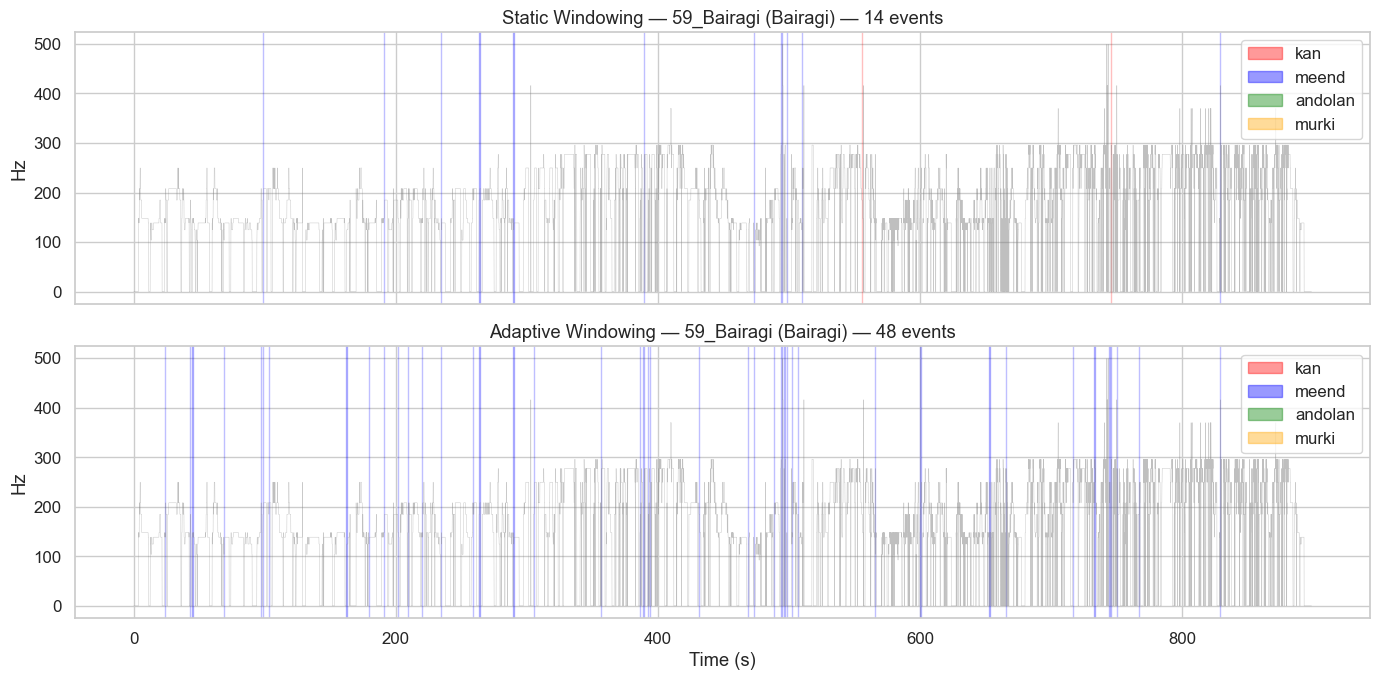

In [8]:
# Visualization: Ornament Detection on Sample Track (Static vs Adaptive)

# Pick a track with many ornaments for visualization
viz_key = max(track_results_static, key=lambda k: len(track_results_static[k]["events"]))
viz_trk = loaded_tracks[viz_key]
viz_pp = preprocessed[viz_key]

color_map = {"kan": "red", "meend": "blue", "andolan": "green", "murki": "orange"}
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, (results, title_label) in zip(axes, [
    (track_results_static, "Static"),
    (track_results_adaptive, "Adaptive"),
]):
    viz_res = results[viz_key]
    ax.plot(viz_trk.f0_times, viz_pp["quant_hz"], lw=0.3, color="grey", alpha=0.5)
    for ev in viz_res["events"]:
        c = color_map.get(ev.label, "black")
        ax.axvspan(ev.start_time, ev.end_time, alpha=0.25, color=c)
    ax.set_ylabel("Hz")
    ax.set_title(f"{title_label} Windowing — {viz_key} ({viz_trk.raga}) — {len(viz_res['events'])} events")
    ax.legend(handles=[Patch(color=c, alpha=0.4, label=l) for l, c in color_map.items()], loc="upper right")

axes[1].set_xlabel("Time (s)")
plt.tight_layout(); plt.show()

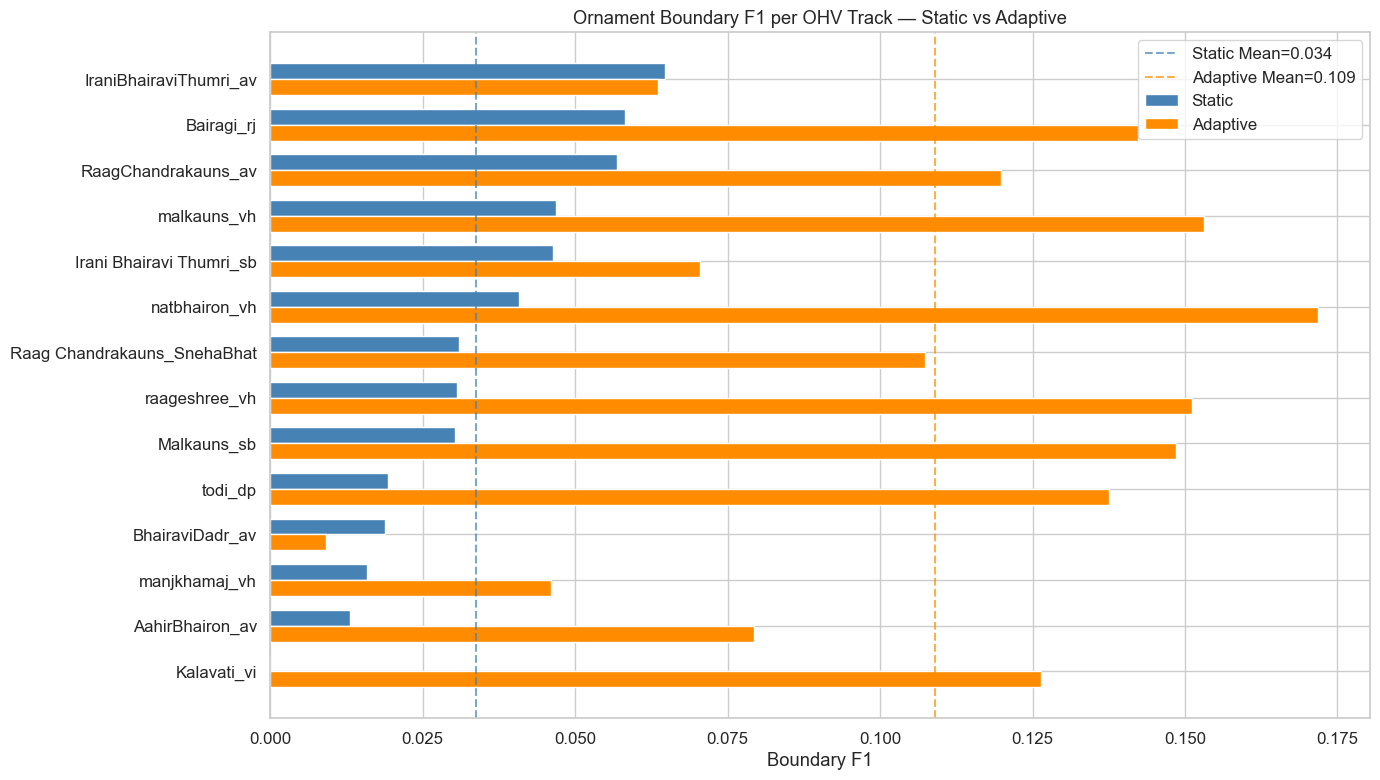

In [9]:
# Per-Track Boundary F1 Bar Chart — Static vs Adaptive

merged = bhr_df_static[["ohv_track"]].copy()
merged["Static F1"] = bhr_df_static["f1"].values
merged["Adaptive F1"] = bhr_df_adaptive["f1"].values
merged = merged.sort_values("Static F1", ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))
y = np.arange(len(merged))
bar_h = 0.35

ax.barh(y + bar_h / 2, merged["Static F1"], bar_h, color="steelblue", label="Static")
ax.barh(y - bar_h / 2, merged["Adaptive F1"], bar_h, color="darkorange", label="Adaptive")
ax.set_yticks(y)
ax.set_yticklabels(merged["ohv_track"])
ax.set_xlabel("Boundary F1")
ax.set_title("Ornament Boundary F1 per OHV Track — Static vs Adaptive")
ax.axvline(bhr_df_static["f1"].mean(), color="steelblue", linestyle="--", alpha=0.7,
           label=f"Static Mean={bhr_df_static['f1'].mean():.3f}")
ax.axvline(bhr_df_adaptive["f1"].mean(), color="darkorange", linestyle="--", alpha=0.7,
           label=f"Adaptive Mean={bhr_df_adaptive['f1'].mean():.3f}")
ax.legend()
plt.tight_layout(); plt.show()

In [10]:
# Summary

print("=" * 70)
print("MULTI-RAGA EVALUATION SUMMARY (STATIC vs ADAPTIVE)")
print("=" * 70)
print(f"OHV annotation files evaluated:  {len(MAPPING)}")
print(f"Unique Saraga tracks processed:  {len(loaded_tracks)}")
print()

for label, results in [("STATIC", track_results_static), ("ADAPTIVE", track_results_adaptive)]:
    total_events = sum(len(r["events"]) for r in results.values())
    total_phrases = sum(len(r["phrases"]) for r in results.values())
    print(f"--- {label} Windowing ---")
    print(f"  Total phrases detected:   {total_phrases}")
    print(f"  Total ornament events:    {total_events}")

for label, bhr_df in [("STATIC", bhr_df_static), ("ADAPTIVE", bhr_df_adaptive)]:
    print(f"\n--- {label} Ornament Boundary Evaluation ---")
    print(f"  Mean Precision: {bhr_df['precision'].mean():.4f}")
    print(f"  Mean Recall:    {bhr_df['recall'].mean():.4f}")
    print(f"  Mean F1:        {bhr_df['f1'].mean():.4f}")

# Highlight improvement
delta_f1 = bhr_df_adaptive["f1"].mean() - bhr_df_static["f1"].mean()
print(f"\n>>> Adaptive F1 improvement over Static: {delta_f1:+.4f}")

MULTI-RAGA EVALUATION SUMMARY (STATIC vs ADAPTIVE)
OHV annotation files evaluated:  11
Unique Saraga tracks processed:  11

--- STATIC Windowing ---
  Total phrases detected:   708
  Total ornament events:    67
--- ADAPTIVE Windowing ---
  Total phrases detected:   708
  Total ornament events:    267

--- STATIC Ornament Boundary Evaluation ---
  Mean Precision: 0.3948
  Mean Recall:    0.0181
  Mean F1:        0.0338

--- ADAPTIVE Ornament Boundary Evaluation ---
  Mean Precision: 0.4640
  Mean Recall:    0.0632
  Mean F1:        0.1091

>>> Adaptive F1 improvement over Static: +0.0753
